In [1]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import pandas as pd
import pingouin as pg
import seaborn as sns


import TwoPUtils as tpu
import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42


%matplotlib inline

%load_ext autoreload
%autoreload 2
 

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig1_licks')
figdir.mkdir(exist_ok=True, parents=True)

In [4]:
mouse = ctrl_mice[1]
day = 5
sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['reward',])


sess.trial_matrices.keys()


dict_keys(['raw_speed', 'bin_edges', 'bin_centers', 'speed', 'acc', 'licks', '_dt', 'reward', 'nonconsum_licks', 'consum_licks', 'licks_sum', 'licks_rate'])

In [20]:

def make_behavior_dataframe(key, mean=False, omit_only =False, norm=False, rzone_ledge=5):
    rows = []
    x = np.arange(-10,3)
    for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
        for day in range(6):
            
            print(day)
            for mouse in mice:

                if mouse == 'SparseKO_09' and day==2:
                    continue
                print(mouse)
                sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                    'licks_sum', 
                                                                                                                                    'nonconsum_licks', 
                                                                                                                                    'consum_licks', 
                                                                                                                                    'licks_rate', 
                                                                                                                                    'speed', 
                                                                                                                                    'reward', 'acc'])
                # if se
                # sess.novel_arm = stx.ymaze_sess_deets['']

                bin_edges = sess.trial_matrices['bin_edges']
                right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

                if sess.novel_arm==-1:
                    rzone_nov = left_rzone_front
                    rzone_fam = right_rzone_front
                else:
                    rzone_nov = right_rzone_front
                    rzone_fam = left_rzone_front

                for ttype in ('fam', 'nov'):
                    
                    if ttype == 'nov':
                        trial_mask = sess.trial_info["LR"] == sess.novel_arm
                        rzone = rzone_nov
                    else:
                        trial_mask = sess.trial_info["LR"] != sess.novel_arm
                        rzone = rzone_fam

                    if omit_only:
                        trial_mask = trial_mask & (np.nansum(sess.trial_matrices['reward'],axis=1)==0)

                    
                    licks = sess.trial_matrices[key][trial_mask,:]

                    if norm:
                        licks = licks/np.nanmean(licks.ravel())

                    if mean:
                        rzone_dat = np.nanmean(licks[:,rzone-rzone_ledge:rzone+1], axis=0).mean()
                    else:
                        rzone_dat = np.nanmean(licks[:,rzone-rzone_ledge:rzone+1], axis=0).sum()


                    rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)

                    rows.append({'cond': cond,
                                'mouse': mouse,
                                'day': day,
                                'ttype': ttype,
                                'rzone_dat': rzone_dat,
                                'rzone_plot_vec': rzone_plot_vec,
                                })
    return pd.DataFrame(rows)
                    
                

In [21]:
def plot_each_day(df, key, maxy=10, save=True):
    for day in range(6):

        x = np.arange(-10,3)
        fig, ax =plt.subplots(1,2, sharey=True, sharex=True, figsize=[6,3])


        for cond, color in zip(('ctrl', 'ko', 'sparse'), ('black','red', 'purple')):
            for i, ttype in enumerate(('fam', 'nov')):

                mask = (df['cond']==cond) * (df['day']==day) * (df['ttype']==ttype)

                licks = np.vstack(df.loc[mask,'rzone_plot_vec'].values)


                mu, sem = np.nanmean(licks, axis=0), sp.stats.sem(licks, axis=0, nan_policy='omit')
                ax[i].plot(x, mu, color=color)
                ax[i].fill_between(x, mu-sem, mu+sem, color=color, alpha=.4)

        for a in ax.flatten():
            a.fill_betweenx([0,maxy], 0, 2, alpha=.4, color='purple', zorder=-10)
            a.spines['top'].set_visible(False)
            a.spines['right'].set_visible(False)

            a.set_ylabel(key)
            a.set_xlabel('Distance to reward')
        if save:
            fig.savefig(figdir / f"{key}_v_position_day{day}.pdf")

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


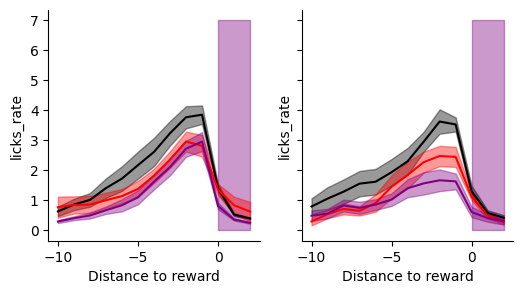

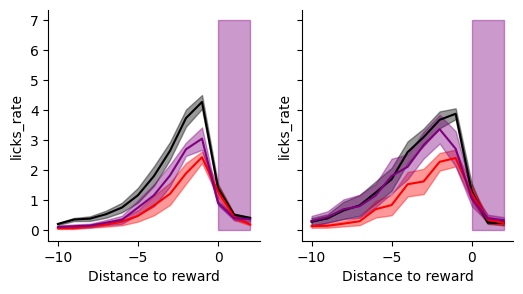

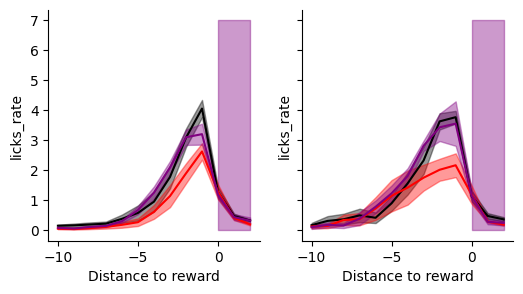

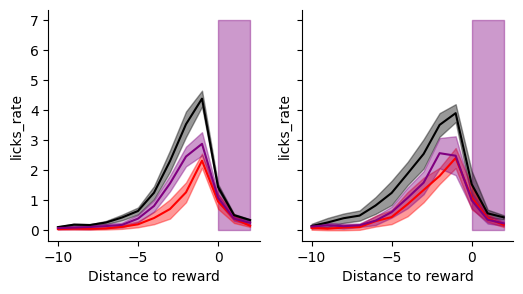

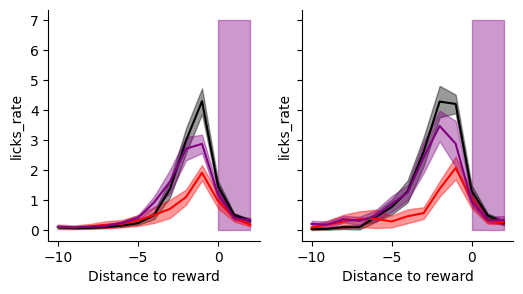

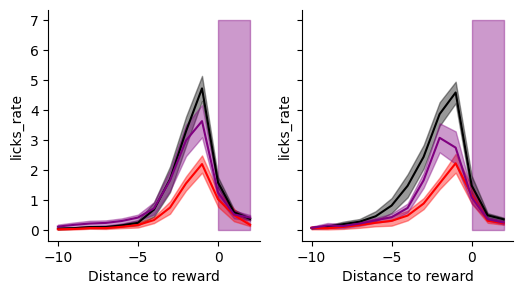

In [45]:
df = make_behavior_dataframe('licks_rate', mean=True)
plot_each_day(df,'licks_rate', maxy=7)

Text(0, 0.5, 'lick rate')

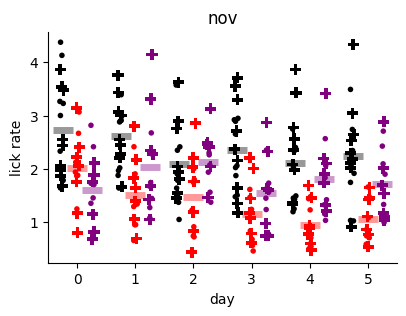

In [46]:


fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
ax.set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('lick rate')


# fig.savefig(figdir / "lick_rate_summary.pdf")


In [47]:
import statsmodels.formula.api as smf

df['rank_lick_rate'] = df['rzone_dat'].rank()
mdl = smf.mixedlm('rank_lick_rate ~   C(day) + C(ttype) + C(cond)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:               MixedLM  Dependent Variable:  rank_lick_rate
No. Observations:    274      Method:              REML          
No. Groups:          23       Scale:               2949.0095     
Min. group size:     10       Log-Likelihood:      -1472.4773    
Max. group size:     12       Converged:           Yes           
Mean group size:     11.9                                        
-----------------------------------------------------------------
                   Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------
Intercept          200.367   16.579 12.086 0.000  167.873 232.861
C(day)[T.1]         -5.826   11.323 -0.515 0.607  -28.019  16.367
C(day)[T.2]        -21.942   11.474 -1.912 0.056  -44.431   0.546
C(day)[T.3]        -40.087   11.323 -3.540 0.000  -62.280 -17.894
C(day)[T.4]        -47.109   11.323 -4.160 0.000  -69.302 -24.915
C(day)[T.5]        -41.587   11.323 -3.673 0.000  -63.780 -19.394
C(ttype)[T.nov]     15.394    6.561  2.346 0.019    2.534  28.254
C(cond)[T.ko]      -95.115   21.939 -4.336 0.000 -138.114 -52.116
C(cond)[T.sparse]  -52.095   21.962 -2.372 0.018  -95.140  -9.051
Group Var         1649.370   11.498                              
=================================================================

"""

Shapiro-Wilk: W=0.996, p=0.622
D'Agostino: χ²=1.240, p=0.538


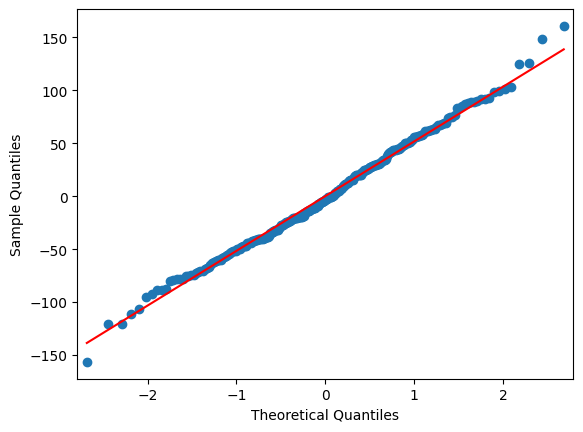

In [48]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(mdl_result.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(mdl_result.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(mdl_result.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [49]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                             chi2                  P>chi2  df constraint
Intercept  [[146.06793521766932]]  1.2545544190456466e-33              1
C(day)     [[30.970598822240568]]    9.49329148526628e-06              5
C(ttype)   [[5.5046084345884765]]    0.018966426314417417              1
C(cond)    [[19.078347053103702]]   7.197630959086227e-05              2

In [50]:
mdl_result.wald_test('C(cond)[T.sparse] = 0')

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[5.62673099]], p-value=0.01768858876570807, df_denom=1>

In [51]:
mdl_result.wald_test('C(cond)[T.ko]=0')

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[18.79673923]], p-value=1.4541552757102814e-05, df_denom=1>

In [52]:
mdl_result.wald_test('C(cond)[T.sparse] = C(cond)[T.ko]')

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[3.41146245]], p-value=0.06474504307257675, df_denom=1>

In [53]:
pg.pairwise_tests(data=df, dv='rzone_dat', between='cond', within='ttype', subject='mouse', parametric=False, padjust='holm')

,Contrast,ttype,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,ttype,-,fam,nov,True,False,NaN,100.0,two-sided,0.259452,NaN,NaN,-0.249250
1,cond,-,ctrl,ko,False,False,60.0,NaN,two-sided,0.001224,0.003671,holm,2.024189
2,cond,-,ctrl,sparse,False,False,50.0,NaN,two-sided,0.054895,0.109790,holm,1.172131
3,cond,-,ko,sparse,False,False,11.0,NaN,two-sided,0.097319,0.109790,holm,-0.914235
4,ttype * cond,fam,ctrl,ko,False,False,59.0,NaN,two-sided,0.002098,0.012587,holm,1.889196
5,ttype * cond,fam,ctrl,sparse,False,False,47.0,NaN,two-sided,0.114161,0.284615,holm,0.994306
6,ttype * cond,fam,ko,sparse,False,False,10.0,NaN,two-sided,0.072844,0.284615,holm,-1.107197
7,ttype * cond,nov,ctrl,ko,False,False,57.0,NaN,two-sided,0.005245,0.026224,holm,1.701970
8,ttype * cond,nov,ctrl,sparse,False,False,49.0,NaN,two-sided,0.071154,0.284615,holm,1.019131
9,ttype * cond,nov,ko,sparse,False,False,16.0,NaN,two-sided,0.317599,0.317599,holm,-0.613728


0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


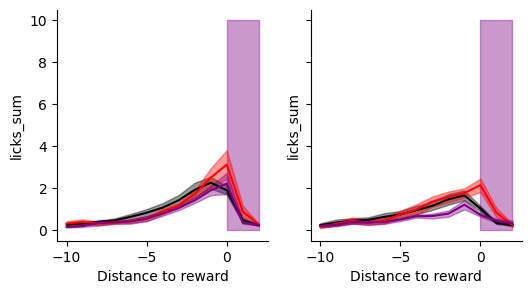

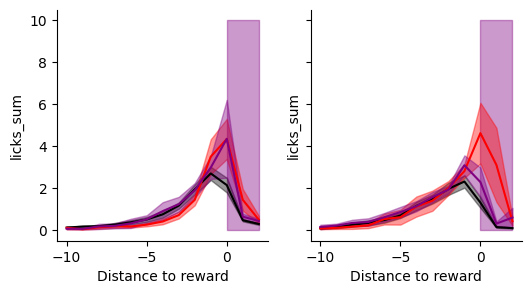

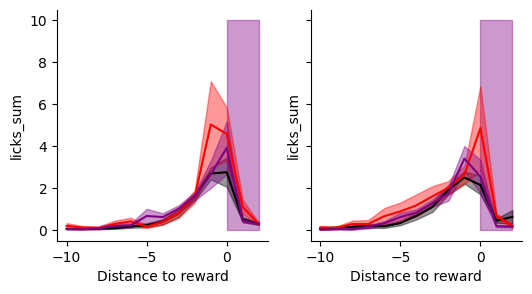

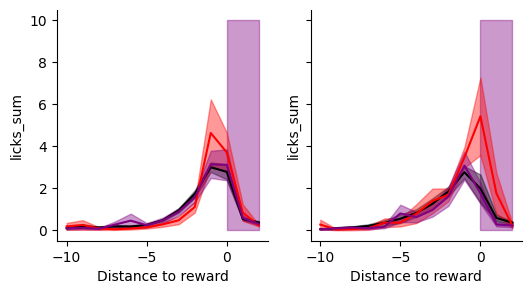

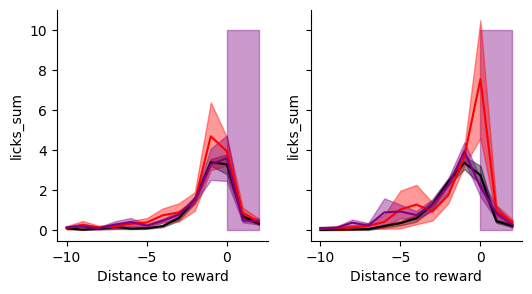

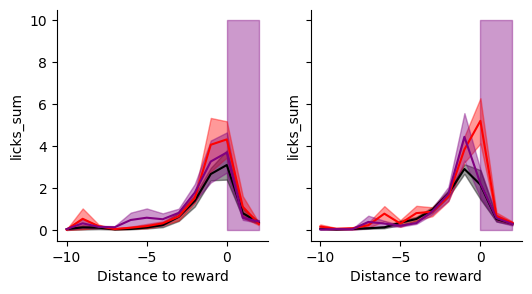

In [54]:
df = make_behavior_dataframe('licks_sum', mean=False)
plot_each_day(df,'licks_sum', maxy=10)

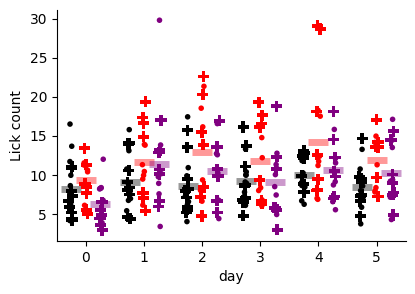

In [55]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.set_ylabel('Lick count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


fig.savefig(figdir / "licks_sum_summary.pdf")


In [56]:
import statsmodels.formula.api as smf

df['rank_lick_rate'] = df['rzone_dat'].rank()
mdl = smf.mixedlm('rank_lick_rate ~   C(day) + C(ttype) + C(cond)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
================================================================
Model:              MixedLM  Dependent Variable:  rank_lick_rate
No. Observations:   274      Method:              REML          
No. Groups:         23       Scale:               3386.7101     
Min. group size:    10       Log-Likelihood:      -1493.3389    
Max. group size:    12       Converged:           Yes           
Mean group size:    11.9                                        
----------------------------------------------------------------
                   Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------
Intercept           82.022   19.626  4.179 0.000  43.555 120.488
C(day)[T.1]         47.913   12.135  3.948 0.000  24.130  71.696
C(day)[T.2]         37.952   12.297  3.086 0.002  13.851  62.053
C(day)[T.3]         38.152   12.135  3.144 0.002  14.369  61.936
C(day)[T.4]         62.935   12.135  5.186 0.000  39.151  86.718
C(day)[T.5]         45.283   12.135  3.732 0.000  21.499  69.066
C(ttype)[T.nov]     -2.409    7.031 -0.343 0.732 -16.190  11.373
C(cond)[T.ko]       48.298   26.677  1.810 0.070  -3.989 100.585
C(cond)[T.sparse]    9.230   26.700  0.346 0.730 -43.100  61.561
Group Var         2520.042   15.859                             
================================================================

"""

In [57]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                              chi2                  P>chi2  df constraint
Intercept    [[17.46572144060534]]  2.9253498386669146e-05              1
C(day)       [[30.07241513232642]]  1.4272341721875584e-05              5
C(ttype)   [[0.11735437618216349]]      0.7319217862753815              1
C(cond)      [[3.523313293697151]]      0.1717600821980067              2

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


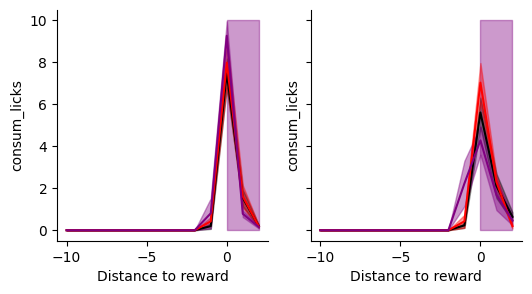

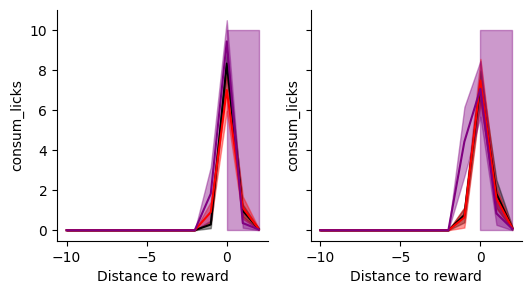

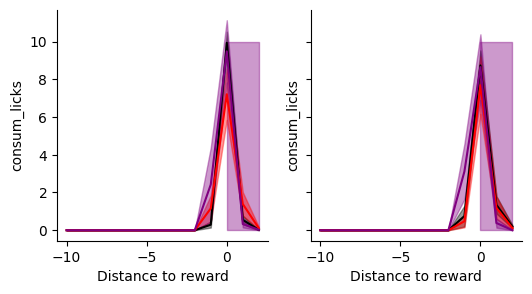

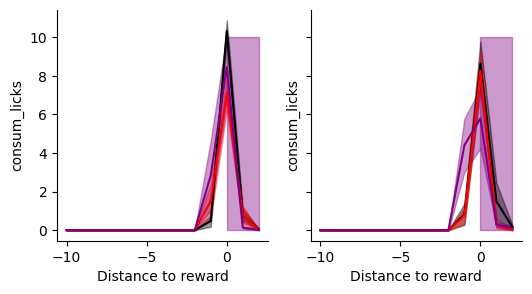

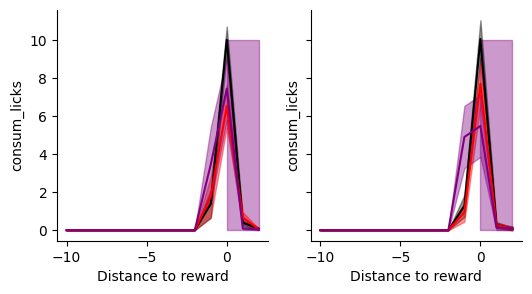

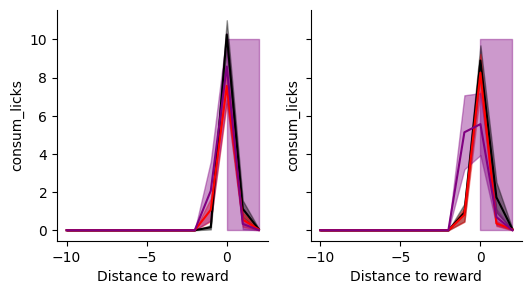

In [58]:
df = make_behavior_dataframe('consum_licks', mean=False)
plot_each_day(df,'consum_licks')

In [59]:


rows = []
x = np.arange(-10,3)
for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    for day in range(6):
        
        print(day)
        for mouse in mice:

            if mouse == 'SparseKO_09' and day==2:
                continue
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                'licks_sum', 
                                                                                                                                'nonconsum_licks', 
                                                                                                                                'consum_licks', 
                                                                                                                                'licks_rate', 'speed'])
            # if se
            # sess.novel_arm = stx.ymaze_sess_deets['']

            bin_edges = sess.trial_matrices['bin_edges']
            right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            if sess.novel_arm==-1:
                rzone_nov = left_rzone_front
                rzone_fam = right_rzone_front
            else:
                rzone_nov = right_rzone_front
                rzone_fam = left_rzone_front

            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                    rzone = rzone_nov
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
                    rzone = rzone_fam

                
                licks = sess.trial_matrices['consum_licks'][trial_mask,:]
                
                rows.append({'cond': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'licks': np.nansum(licks, axis=1).mean(axis=0),
                            })
df = pd.DataFrame(rows)
                    
                

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


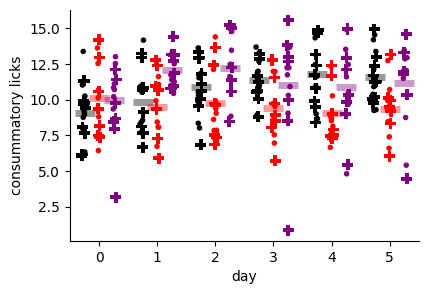

In [60]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='licks',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='licks',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('consummatory licks')


fig.savefig(figdir / "consum_licks_summary.pdf")


In [61]:
import statsmodels.formula.api as smf

df['rank_licks'] = df['licks'].rank()
mdl = smf.mixedlm('rank_licks ~   C(day) + C(ttype) + C(cond)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:               MixedLM    Dependent Variable:    rank_licks
No. Observations:    274        Method:                REML      
No. Groups:          23         Scale:                 2783.5108 
Min. group size:     10         Log-Likelihood:        -1470.9801
Max. group size:     12         Converged:             Yes       
Mean group size:     11.9                                        
-----------------------------------------------------------------
                   Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------
Intercept          117.130   20.705  5.657 0.000   76.549 157.710
C(day)[T.1]         24.652   11.001  2.241 0.025    3.091  46.214
C(day)[T.2]         39.332   11.148  3.528 0.000   17.482  61.182
C(day)[T.3]         38.065   11.001  3.460 0.001   16.504  59.627
C(day)[T.4]         32.022   11.001  2.911 0.004   10.460  53.583
C(day)[T.5]         39.413   11.001  3.583 0.000   17.851  60.975
C(ttype)[T.nov]     -3.606    6.375 -0.566 0.572  -16.100   8.888
C(cond)[T.ko]      -43.229   29.003 -1.490 0.136 -100.074  13.616
C(cond)[T.sparse]   21.584   29.020  0.744 0.457  -35.294  78.462
Group Var         3080.204   20.648                              
=================================================================

"""

In [62]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                             chi2                  P>chi2  df constraint
Intercept   [[32.00268123815763]]  1.5395993233412828e-08              1
C(day)     [[19.182580982181783]]    0.001777266017069413              5
C(ttype)    [[0.319970855536187]]      0.5716251602332572              1
C(cond)     [[4.629201020258872]]     0.09880564797439839              2

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


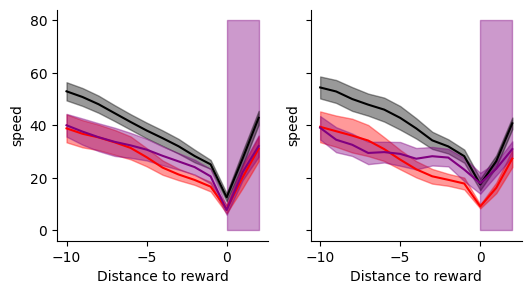

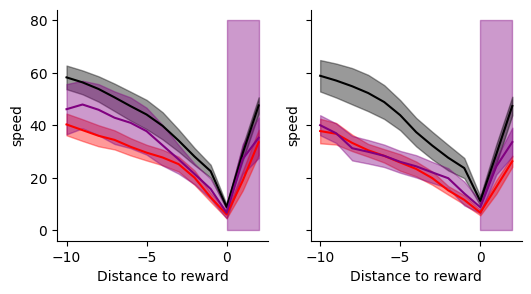

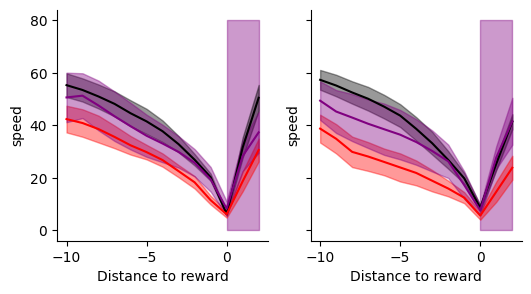

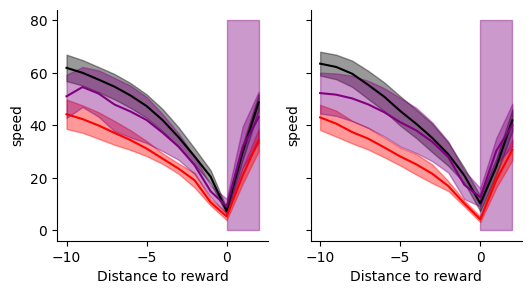

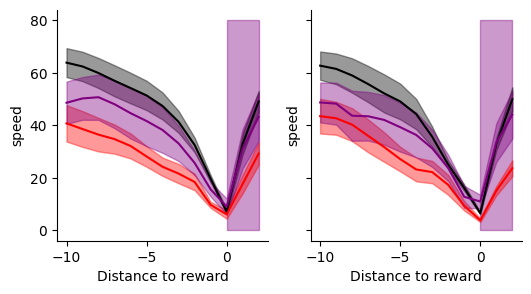

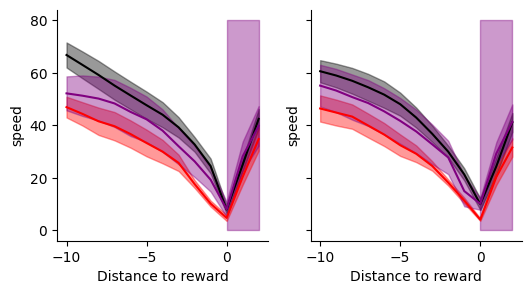

In [63]:
df = make_behavior_dataframe('speed', mean=True)
plot_each_day(df,'speed',maxy=80)

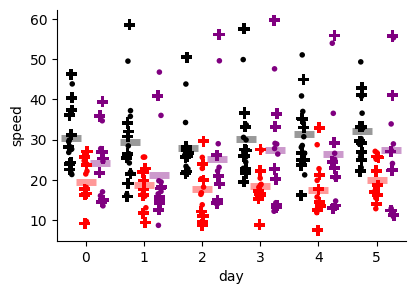

In [64]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('speed')


fig.savefig(figdir / "speed_summary.pdf")


In [65]:
rows = []
for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    for day in range(6):
        
        print(day)
        for mouse in mice:

            if mouse == 'SparseKO_09' and day==2:
                continue
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                'licks_sum', 
                                                                                                                                'nonconsum_licks', 
                                                                                                                                'consum_licks', 
                                                                                                                                'licks_rate', 'speed'])
            # if se
            # sess.novel_arm = stx.ymaze_sess_deets['']

            bin_edges = sess.trial_matrices['bin_edges']
            right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            if sess.novel_arm==-1:
                rzone_nov = left_rzone_front
                rzone_fam = right_rzone_front
            else:
                rzone_nov = right_rzone_front
                rzone_fam = left_rzone_front

            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                    rzone = rzone_nov
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
                    rzone = rzone_fam

                
                cv = sp.stats.variation(sess.trial_matrices['speed'][trial_mask,:],axis=0, nan_policy='omit')
                rzone_plot_vec = cv[rzone-10:rzone+3]
                # print(cv)
                rows.append({'cond': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'rzone_dat': cv[rzone-5:rzone+1].mean(),
                            'rzone_plot_vec': rzone_plot_vec,
                            })
df = pd.DataFrame(rows)

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


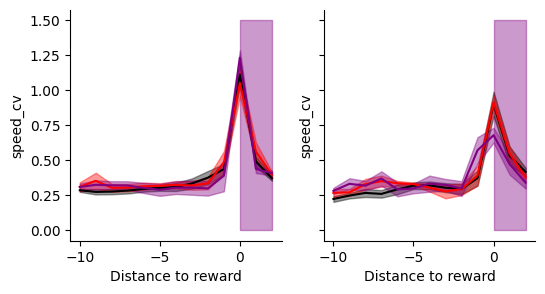

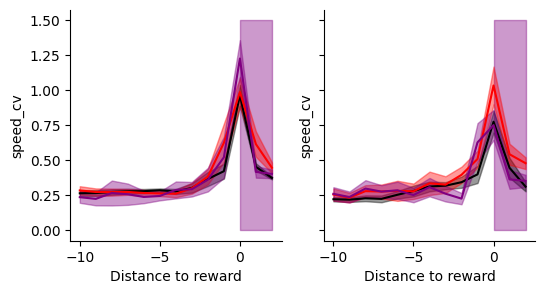

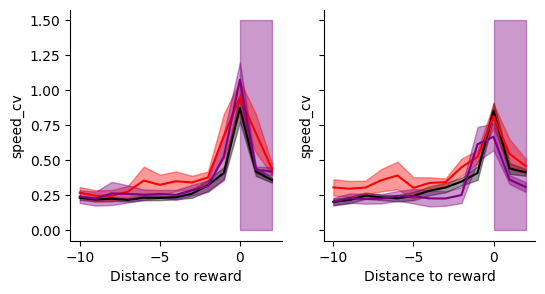

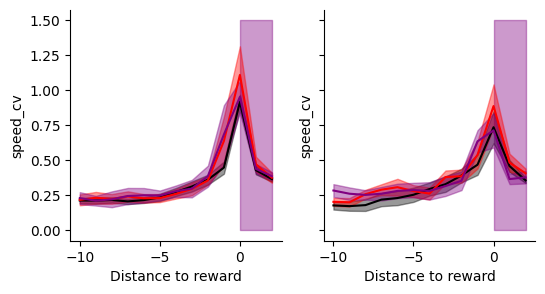

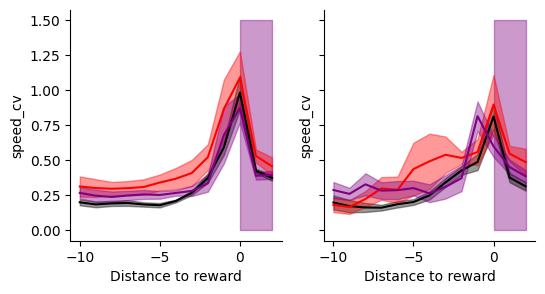

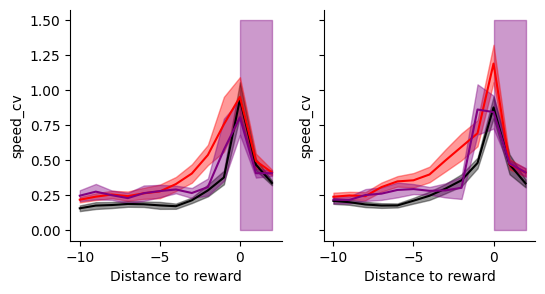

In [66]:
plot_each_day(df,'speed_cv',maxy=1.5)

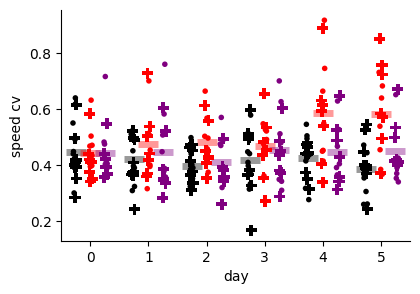

In [67]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_dat',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=df,
            x='day',
            y='rzone_dat',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko', 'sparse'],
            dodge = .5,
            palette = ['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    # ax[i].set_title(nov)

# for a in ax:
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('speed cv')


fig.savefig(figdir / "speed_summary.pdf")


In [68]:
import statsmodels.formula.api as smf

df['rank_speedcv'] = df['rzone_dat'].rank()
mdl = smf.mixedlm('rank_speedcv ~   C(day) + C(ttype) * C(cond)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Mixed Linear Model Regression Results
================================================================================
Model:                    MixedLM        Dependent Variable:        rank_speedcv
No. Observations:         274            Method:                    REML        
No. Groups:               23             Scale:                     4441.8256   
Min. group size:          10             Log-Likelihood:            -1513.9912  
Max. group size:          12             Converged:                 Yes         
Mean group size:          11.9                                                  
--------------------------------------------------------------------------------
                                   Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------
Intercept                          119.245   18.231  6.541 0.000  83.514 154.977
C(day)[T.1]                         -4.174   13.897 -0.300 0.764 -31.411  23.063
C(day)[T.2]                        -15.355   14.080 -1.091 0.275 -42.952  12.242
C(day)[T.3]                         -0.109   13.897 -0.008 0.994 -27.346  27.129
C(day)[T.4]                         16.130   13.897  1.161 0.246 -11.107  43.368
C(day)[T.5]                          3.370   13.897  0.242 0.808 -23.868  30.607
C(ttype)[T.nov]                     -4.278   12.826 -0.334 0.739 -29.417  20.861
C(cond)[T.ko]                       60.635   23.988  2.528 0.011  13.619 107.650
C(cond)[T.sparse]                   18.821   24.047  0.783 0.434 -28.310  65.952
C(ttype)[T.nov]:C(cond)[T.ko]      -11.603   19.391 -0.598 0.550 -49.610  26.403
C(ttype)[T.nov]:C(cond)[T.sparse]  -16.722   19.524 -0.856 0.392 -54.989  21.544
Group Var                         1525.415    9.396                             
================================================================================

"""

In [69]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                    chi2                 P>chi2  df constraint
Intercept         [[42.783578927689575]]  6.114326844250696e-11              1
C(day)             [[5.310556935991995]]     0.3791662102691043              5
C(ttype)          [[0.1112342940900986]]     0.7387432617180493              1
C(cond)            [[6.516273438228347]]   0.038459993065944546              2
C(ttype):C(cond)  [[0.7966576944365816]]     0.6714411897855326              2

In [70]:
mdl_result.wald_test('C(cond)[T.sparse]=0')

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[0.61260787]], p-value=0.43380758840115696, df_denom=1>

In [71]:
mdl_result.wald_test('C(cond)[T.ko]=0')

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[6.38940133]], p-value=0.011480374072996557, df_denom=1>

In [72]:
mdl_result.wald_test('C(cond)[T.sparse]=C(cond)[T.ko]')

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[2.68908301]], p-value=0.10103794498324657, df_denom=1>

Shapiro-Wilk: W=0.989, p=0.0319
D'Agostino: χ²=14.790, p=0.000614


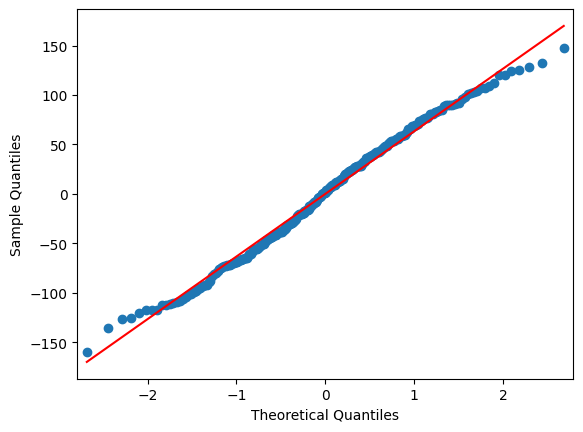

In [74]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(mdl_result.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(mdl_result.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(mdl_result.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [75]:
import pickle

with open('/home/mplitt/shuffle_pkls/licks_sum_mixedlm_shuffle.pkl', 'rb') as file:
    res_dict = pickle.load(file)

In [76]:
res_dict.keys()

dict_keys(['rzone_licks', 'rzone_licks_rank'])

In [77]:
for stat in res_dict.keys():
    coef = res_dict[stat]['genotype coef.']
    shuff_coef = res_dict[stat]['shuffle genotype coef.']

    p = (1.*(coef<shuff_coef)).sum()/shuff_coef.shape[0]
    p = np.minimum(p, 1-p)
    print(f"{stat} : p={p}")

rzone_licks : p=0.05139860139860142
rzone_licks_rank : p=0.048164335664335645


### Only omission trial licks sum vs lick rate, accounting for speed

In [115]:

def make_rzone_dataframe(lick_key, mean=False, omit_only =False):
    rows = []
    x = np.arange(-10,3)
    for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
        for day in range(6):
            
            print(day)
            for mouse in mice:

                if mouse == 'SparseKO_09' and day==2:
                    continue
                print(mouse)
                sess = stx.utilities.load_vr_day(mouse, day,verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/', trial_mat_keys=['licks', 
                                                                                                                                    'licks_sum', 
                                                                                                                                    'nonconsum_licks', 
                                                                                                                                    'consum_licks', 
                                                                                                                                    'licks_rate', 
                                                                                                                                    'speed', 
                                                                                                                                    'reward'])
                # if se
                # sess.novel_arm = stx.ymaze_sess_deets['']

                bin_edges = sess.trial_matrices['bin_edges']
                right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

                if sess.novel_arm==-1:
                    rzone_nov = left_rzone_front
                    rzone_fam = right_rzone_front
                else:
                    rzone_nov = right_rzone_front
                    rzone_fam = left_rzone_front

                for ttype in ('fam', 'nov'):
                    
                    if ttype == 'nov':
                        trial_mask = sess.trial_info["LR"] == sess.novel_arm
                        rzone = rzone_nov
                    else:
                        trial_mask = sess.trial_info["LR"] != sess.novel_arm
                        rzone = rzone_fam

                    if omit_only:
                        trial_mask = trial_mask & (np.nansum(sess.trial_matrices['reward'],axis=1)==0)

                    
                    licks = sess.trial_matrices[lick_key][trial_mask,:]
                    speed = sess.trial_matrices['speed'][trial_mask,:]
                    if mean:
                        rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
                    else:
                        rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).sum()

                    rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()

                    rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)

                    rows.append({'cond': cond,
                                'mouse': mouse,
                                'day': day,
                                'ttype': ttype,
                                'rzone_dat': rzone_dat,
                                'rzone_plot_vec': rzone_plot_vec,
                                'rzone_speed': rzone_speed,
                                })
    return pd.DataFrame(rows)
                    
                

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipyker

4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipyker

4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2


...

4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipyker

SparseKO_13
SparseKO_09
2
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
3
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
4
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)


5
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


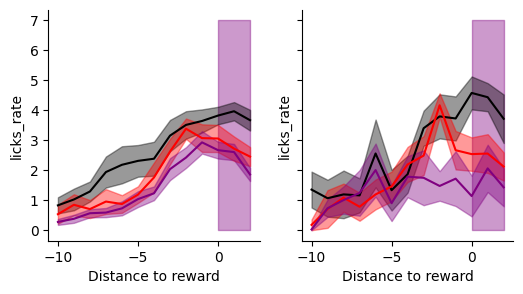

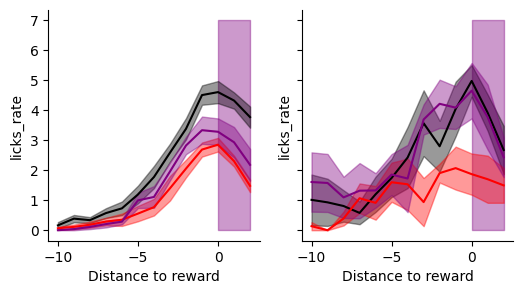

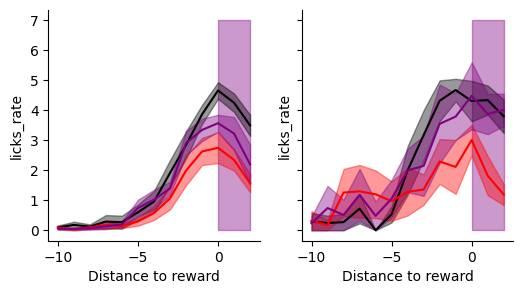

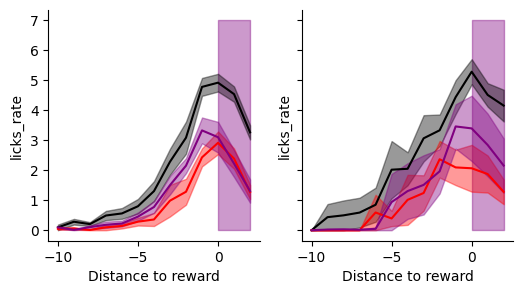

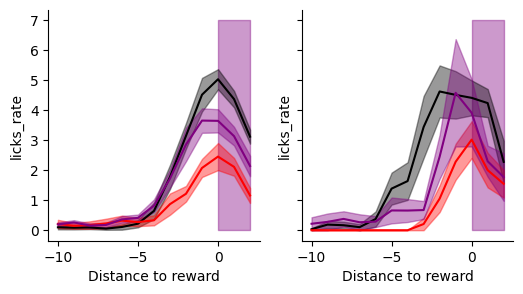

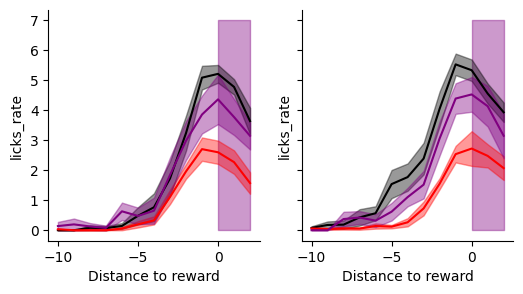

In [116]:
df = make_rzone_dataframe('licks_rate', mean=True, omit_only=True)
plot_each_day(df,'licks_rate', maxy=7,save=False)

In [117]:
df

,cond,mouse,day,ttype,rzone_dat,rzone_plot_vec,rzone_speed
0,ctrl,4467331.1,0,fam,3.310478,"[0.7727450489500833, 0.6644863239374635, 0.418...",22.554307
1,ctrl,4467331.1,0,nov,4.208950,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.15054941...",16.212427
2,ctrl,4467331.2,0,fam,3.720284,"[1.1707282154832572, 1.1701872465154552, 1.769...",28.132599
3,ctrl,4467331.2,0,nov,4.461941,"[3.2452720637015977, 3.7856018319753257, 5.505...",29.361033
4,ctrl,4467332.1,0,fam,5.300780,"[2.5141338407804645, 2.735828205351328, 2.4761...",17.513514
...,...,...,...,...,...,...,...
269,sparse,SparseKO_11,5,nov,2.641587,"[0.0, 0.0, 0.0, 0.600636674875372, 0.0, 0.0, 1...",10.148778
270,sparse,SparseKO_13,5,fam,5.810631,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.50320901...",28.207642
271,sparse,SparseKO_13,5,nov,6.803608,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.691...",31.779747
272,sparse,SparseKO_09,5,fam,4.556783,"[0.0, 1.3605442176864182, 0.0, 0.0, 1.45560407...",13.484788


In [118]:
df = df.dropna()

In [119]:
import statsmodels.formula.api as smf

df['rank_lickrate'] = df['rzone_dat'].rank()
df['rank_speed'] = df['rzone_speed'].rank()
mdl = smf.mixedlm('rank_lickrate ~   C(day) +  C(cond) + C(ttype) + rank_speed', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

/tmp/ipykernel_31681/3860097347.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rank_lickrate'] = df['rzone_dat'].rank()
/tmp/ipykernel_31681/3860097347.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rank_speed'] = df['rzone_speed'].rank()


<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:              MixedLM   Dependent Variable:   rank_lickrate
No. Observations:   251       Method:               REML         
No. Groups:         23        Scale:                1503.6827    
Min. group size:    8         Log-Likelihood:       -1274.1940   
Max. group size:    12        Converged:            Yes          
Mean group size:    10.9                                         
-----------------------------------------------------------------
                   Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------
Intercept          184.084   19.925  9.239 0.000  145.032 223.135
C(day)[T.1]          7.645    9.156  0.835 0.404  -10.301  25.591
C(day)[T.2]          9.393    9.231  1.018 0.309   -8.699  27.486
C(day)[T.3]          6.122    9.070  0.675 0.500  -11.655  23.899
C(day)[T.4]          0.473    9.563  0.049 0.961  -18.269  19.216
C(day)[T.5]         31.602    9.150  3.454 0.001   13.668  49.536
C(cond)[T.ko]     -118.075   23.397 -5.046 0.000 -163.933 -72.217
C(cond)[T.sparse]  -67.403   22.990 -2.932 0.003 -112.462 -22.345
C(ttype)[T.nov]     -1.322    4.972 -0.266 0.790  -11.067   8.422
rank_speed          -0.114    0.056 -2.023 0.043   -0.225  -0.004
Group Var         1937.013   17.755                              
=================================================================

"""

Shapiro-Wilk: W=0.983, p=0.00466
D'Agostino: χ²=14.592, p=0.000678


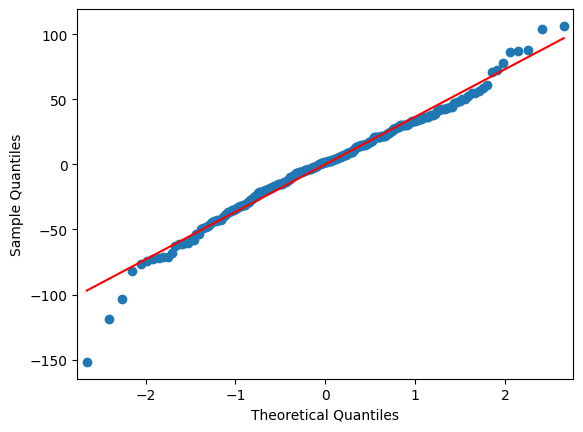

In [120]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(mdl_result.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(mdl_result.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(mdl_result.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipyker

3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipyker

4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9


...

4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipyker

SparseKO_11
SparseKO_13
SparseKO_09
2
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
3
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
4
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
5
SparseKO_02


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)


SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


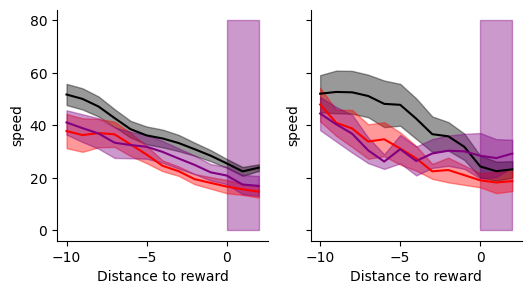

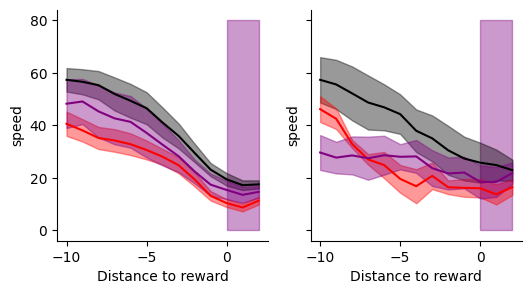

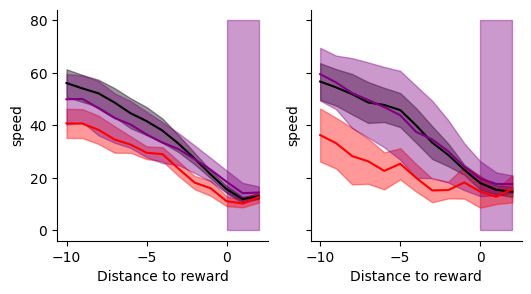

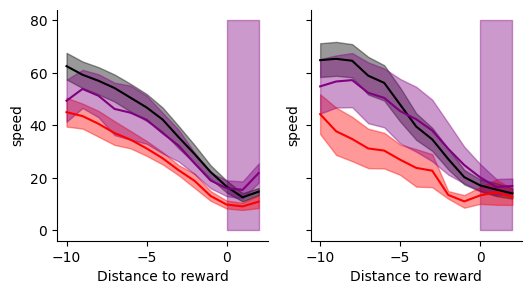

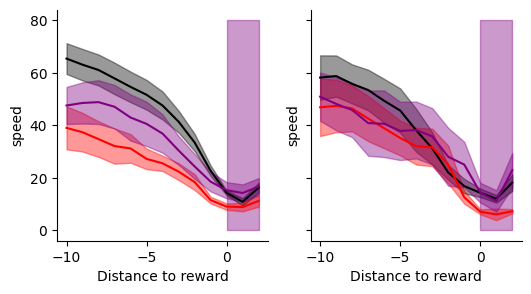

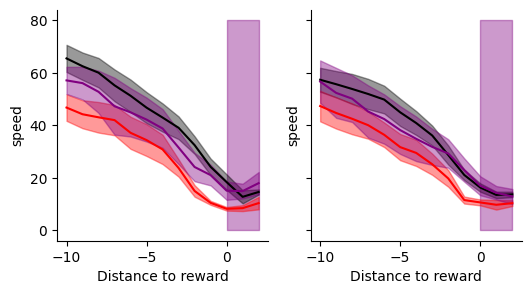

In [121]:
df = make_rzone_dataframe('speed', mean=True, omit_only=True)
plot_each_day(df,'speed',maxy=80, save=False)

In [122]:
df = df.dropna()
# df['rank_lickrate'] = df['rzone_dat'].rank()
df['rank_speed'] = df['rzone_speed'].rank()
mdl = smf.mixedlm('rank_speed ~   C(day) +  C(cond) + C(ttype)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
=================================================================
Model:               MixedLM    Dependent Variable:    rank_speed
No. Observations:    251        Method:                REML      
No. Groups:          23         Scale:                 2026.0693 
Min. group size:     8          Log-Likelihood:        -1305.5609
Max. group size:     12         Converged:             Yes       
Mean group size:     10.9                                        
-----------------------------------------------------------------
                   Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------
Intercept          203.204   16.481 12.330 0.000  170.903 235.505
C(day)[T.1]        -52.094   10.064 -5.176 0.000  -71.819 -32.370
C(day)[T.2]        -56.134   10.062 -5.579 0.000  -75.855 -36.413
C(day)[T.3]        -58.697    9.803 -5.987 0.000  -77.911 -39.483
C(day)[T.4]        -78.120    9.854 -7.928 0.000  -97.433 -58.807
C(day)[T.5]        -68.644    9.629 -7.129 0.000  -87.517 -49.771
C(cond)[T.ko]      -79.153   22.659 -3.493 0.000 -123.565 -34.742
C(cond)[T.sparse]  -19.697   22.654 -0.869 0.385  -64.099  24.704
C(ttype)[T.nov]      5.875    5.758  1.020 0.308   -5.411  17.161
Group Var         1833.476   14.820                              
=================================================================

"""

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipyker

3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipyker

mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7


...

Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02
SparseKO_06
SparseKO_08


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipyker

SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
2
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
3
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
4
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13


/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)
/tmp/ipykernel_31681/1768354550.py:50: RuntimeWarning: Mean of empty slice
  rzone_dat = np.nanmean(licks[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:54: RuntimeWarning: Mean of empty slice
  rzone_speed = np.nanmean(speed[:,rzone-1:rzone+3], axis=0).mean()
/tmp/ipykernel_31681/1768354550.py:56: RuntimeWarning: Mean of empty slice
  rzone_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)


SparseKO_09
5
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


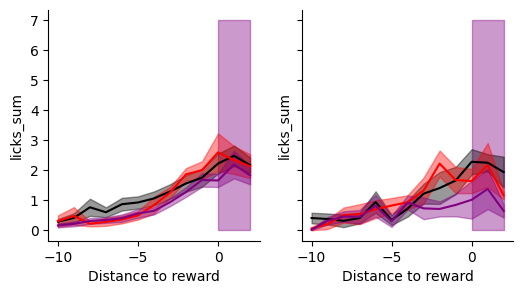

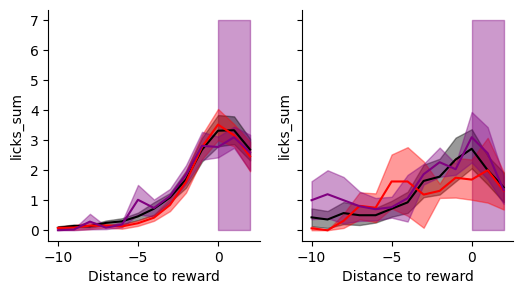

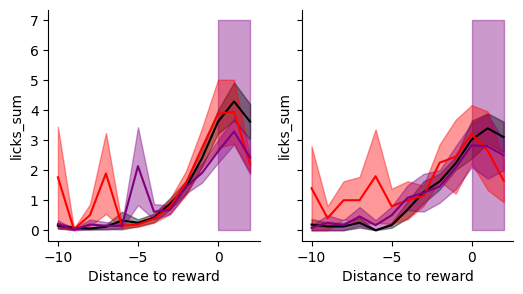

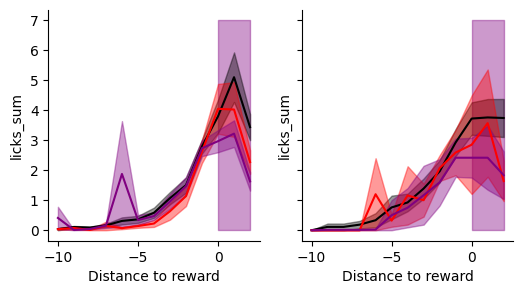

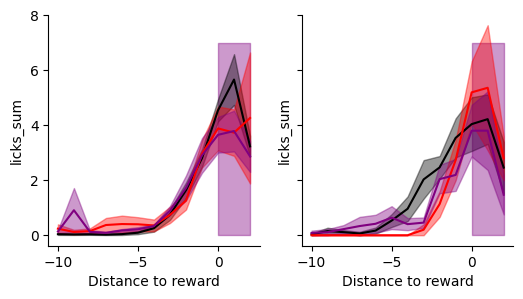

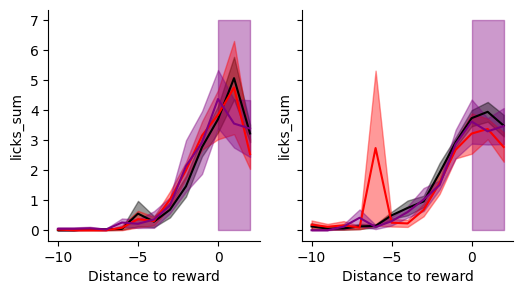

In [123]:
df = make_rzone_dataframe('licks_sum', mean=True, omit_only=True)
plot_each_day(df,'licks_sum', maxy=7,save=False)

In [124]:
df = df[(df['ttype']=='fam') * (df['cond']!='sparse')]
df = df.dropna()

In [125]:
df['rank_licks'] = df['rzone_dat'].rank()
mdl = smf.mixedlm('rank_licks ~   C(day) *  C(cond)', df, groups=df['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                Mixed Linear Model Regression Results
======================================================================
Model:                  MixedLM     Dependent Variable:     rank_licks
No. Observations:       96          Method:                 REML      
No. Groups:             16          Scale:                  227.0025  
Min. group size:        6           Log-Likelihood:         -377.7630 
Max. group size:        6           Converged:              Yes       
Mean group size:        6.0                                           
----------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
----------------------------------------------------------------------
Intercept                  23.944    8.854  2.705 0.007   6.592 41.297
C(day)[T.1]                21.167    7.102  2.980 0.003   7.246 35.087
C(day)[T.2]                29.444    7.102  4.146 0.000  15.524 43.365
C(day)[T.3]                35.056    7.102  4.936 0.000  21.135 48.976
C(day)[T.4]                41.889    7.102  5.898 0.000  27.968 55.809
C(day)[T.5]                36.611    7.102  5.155 0.000  22.691 50.532
C(cond)[T.ko]               3.484   13.385  0.260 0.795 -22.751 29.719
C(day)[T.1]:C(cond)[T.ko]  -2.952   10.738 -0.275 0.783 -23.998 18.094
C(day)[T.2]:C(cond)[T.ko] -14.587   10.738 -1.358 0.174 -35.633  6.459
C(day)[T.3]:C(cond)[T.ko] -14.127   10.738 -1.316 0.188 -35.173  6.919
C(day)[T.4]:C(cond)[T.ko] -15.675   10.738 -1.460 0.144 -36.721  5.371
C(day)[T.5]:C(cond)[T.ko] -12.040   10.738 -1.121 0.262 -33.086  9.006
Group Var                 478.466   14.188                            
======================================================================

"""